In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from xgboost import XGBClassifier

In [2]:
LABELS_CSV = r"C:\Users\DELL\Documents\repertoire_projets\Machine_learning\Training_database_float16\pipe_detection_label.csv"
DATA_DIR = r"C:\Users\DELL\Documents\repertoire_projets\Machine_learning\Training_database_float16"

print("CSV exists:", os.path.exists(LABELS_CSV))
print("DATA_DIR exists:", os.path.exists(DATA_DIR))

CSV exists: True
DATA_DIR exists: True


In [5]:
df = pd.read_csv(LABELS_CSV, sep=";")
df.columns = df.columns.str.strip()

print("Colonnes :", df.columns.tolist())
display(df.head())
print("Shape :", df.shape)

Colonnes : ['field_file', 'label', 'width_m', 'coverage_type', 'shape', 'noisy', 'noise_type', 'pipe_type']


,field_file,label,width_m,coverage_type,shape,noisy,noise_type,pipe_type
0,sample_00000_perfect_straight_clean_field.npz,1,62.40,perfect,straight,False,NaN,single
1,sample_00001_perfect_straight_clean_field.npz,1,41.08,perfect,straight,False,NaN,single
2,sample_00002_perfect_straight_clean_field.npz,1,42.34,perfect,straight,False,NaN,single
3,sample_00003_perfect_straight_clean_field.npz,1,4.96,perfect,straight,False,NaN,single
4,sample_00004_perfect_straight_clean_field.npz,1,35.96,perfect,straight,False,NaN,single


Shape : (2833, 8)


In [6]:
FILE_COL = "field_file"
PIPE_COL = "pipe_type"

# Task 4:
# 0 = single
# 1 = parallel
df = df[df[PIPE_COL].isin(["single", "parallel"])].copy()

df["task4_label"] = (df[PIPE_COL] == "parallel").astype(int)

print(df["task4_label"].value_counts())
print(df["task4_label"].value_counts(normalize=True).round(3))
display(df[[FILE_COL, PIPE_COL, "task4_label"]].head())

task4_label
0    2333
1     500
Name: count, dtype: int64
task4_label
0    0.824
1    0.176
Name: proportion, dtype: float64


,field_file,pipe_type,task4_label
0,sample_00000_perfect_straight_clean_field.npz,single,0
1,sample_00001_perfect_straight_clean_field.npz,single,0
2,sample_00002_perfect_straight_clean_field.npz,single,0
3,sample_00003_perfect_straight_clean_field.npz,single,0
4,sample_00004_perfect_straight_clean_field.npz,single,0


In [7]:
df["path"] = df[FILE_COL].apply(lambda f: os.path.join(DATA_DIR, str(f)))
df["exists"] = df["path"].apply(os.path.exists)

print("Shape avant filtre :", df.shape)
print("Fichiers manquants :", (~df["exists"]).sum())

df = df[df["exists"]].copy().reset_index(drop=True)

print("Shape après filtre :", df.shape)
print(df["task4_label"].value_counts())
display(df.head())

Shape avant filtre : (2833, 11)
Fichiers manquants : 0
Shape après filtre : (2833, 11)
task4_label
0    2333
1     500
Name: count, dtype: int64


,field_file,label,width_m,coverage_type,shape,noisy,noise_type,pipe_type,task4_label,path,exists
0,sample_00000_perfect_straight_clean_field.npz,1,62.40,perfect,straight,False,NaN,single,0,C:\Users\DELL\Documents\repertoire_projets\Mac...,True
1,sample_00001_perfect_straight_clean_field.npz,1,41.08,perfect,straight,False,NaN,single,0,C:\Users\DELL\Documents\repertoire_projets\Mac...,True
2,sample_00002_perfect_straight_clean_field.npz,1,42.34,perfect,straight,False,NaN,single,0,C:\Users\DELL\Documents\repertoire_projets\Mac...,True
3,sample_00003_perfect_straight_clean_field.npz,1,4.96,perfect,straight,False,NaN,single,0,C:\Users\DELL\Documents\repertoire_projets\Mac...,True
4,sample_00004_perfect_straight_clean_field.npz,1,35.96,perfect,straight,False,NaN,single,0,C:\Users\DELL\Documents\repertoire_projets\Mac...,True


In [9]:
train_df, test_df = train_test_split(
    df,
    test_size=0.15,
    random_state=19,
    stratify=df["task4_label"]
)

train_df, val_df = train_test_split(
    train_df,
    test_size=0.1765,
    random_state=19,
    stratify=train_df["task4_label"]
)

print("Train:", train_df.shape)
print("Val  :", val_df.shape)
print("Test :", test_df.shape)

Train: (1982, 11)
Val  : (426, 11)
Test : (425, 11)


In [10]:
def load_npz(path):
    z = np.load(path)

    if "data" in z.files:
        x = z["data"]
    elif "arr_0" in z.files:
        x = z["arr_0"]
    else:
        x = z[z.files[0]]

    x = np.array(x).astype(np.float32)

    if x.ndim == 2:
        x = x[..., None]
    elif x.ndim == 3:
        if x.shape[0] in [3, 4] and x.shape[-1] not in [3, 4]:
            x = np.transpose(x, (1, 2, 0))
    else:
        raise ValueError(f"Shape inattendue: {x.shape}")

    return x

In [11]:
def crop_to_valid_bbox(x, margin=5):
    valid = ~np.isnan(x).all(axis=-1)
    if not valid.any():
        return None

    rows = np.where(valid.any(axis=1))[0]
    cols = np.where(valid.any(axis=0))[0]

    rmin, rmax = rows[0], rows[-1]
    cmin, cmax = cols[0], cols[-1]

    rmin = max(0, rmin - margin)
    cmin = max(0, cmin - margin)
    rmax = min(x.shape[0] - 1, rmax + margin)
    cmax = min(x.shape[1] - 1, cmax + margin)

    return x[rmin:rmax+1, cmin:cmax+1, :]


def add_mask_and_fillnan(x):
    valid = ~np.isnan(x).all(axis=-1)
    mask = valid.astype(np.float32)[..., None]
    x_filled = np.nan_to_num(x, nan=0.0).astype(np.float32)
    return np.concatenate([x_filled, mask], axis=-1)


def normalize_per_channel_on_valid(xm, eps=1e-6):
    x = xm[..., :-1]
    m = xm[..., -1:]
    x_out = x.copy()

    for c in range(x.shape[-1]):
        vals = x[..., c][m[..., 0] > 0]
        vals = vals[np.isfinite(vals)]

        if len(vals) == 0:
            mean, std = 0.0, 1.0
        else:
            mean = np.mean(vals)
            std = np.std(vals)
            if std < eps:
                std = 1.0

        x_out[..., c] = (x[..., c] - mean) / std

    return np.concatenate([x_out, m], axis=-1)


def pad_to_square(x, pad_value=0.0):
    H, W, C = x.shape
    S = max(H, W)

    out = np.full((S, S, C), pad_value, dtype=x.dtype)
    top = (S - H) // 2
    left = (S - W) // 2
    out[top:top+H, left:left+W, :] = x

    return out


def resize_xm(xm, out_size=224):
    img = xm[..., :-1]
    msk = xm[..., -1]

    img_r = cv2.resize(img, (out_size, out_size), interpolation=cv2.INTER_LINEAR)
    msk_r = cv2.resize(msk, (out_size, out_size), interpolation=cv2.INTER_NEAREST)

    return np.concatenate([img_r, msk_r[..., None]], axis=-1).astype(np.float32)


def preprocess_npz(path, margin=5, out_size=224):
    x = load_npz(path)
    x_crop = crop_to_valid_bbox(x, margin=margin)

    if x_crop is None:
        c = x.shape[-1] if x.ndim == 3 else 4
        return np.zeros((out_size, out_size, c + 1), dtype=np.float32)

    xm = add_mask_and_fillnan(x_crop)
    xm = normalize_per_channel_on_valid(xm)
    xm = pad_to_square(xm, pad_value=0.0)
    xm = resize_xm(xm, out_size=out_size)

    return xm

(224, 224, 5) float32


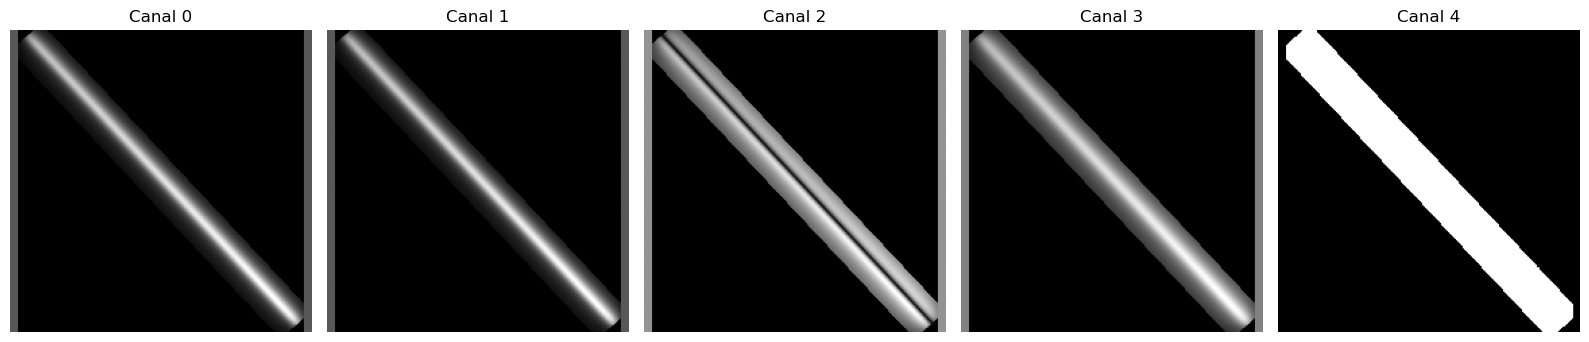

In [12]:
OUT_SIZE = 224

sample_path = train_df.iloc[0]["path"]
xm = preprocess_npz(sample_path, margin=5, out_size=OUT_SIZE)

print(xm.shape, xm.dtype)

n_show = min(5, xm.shape[-1])
plt.figure(figsize=(16, 4))
for i in range(n_show):
    plt.subplot(1, n_show, i + 1)
    plt.imshow(xm[..., i], cmap="gray")
    plt.title(f"Canal {i}")
    plt.axis("off")
plt.tight_layout()
plt.show()

In [13]:
class Task4Dataset(Dataset):
    def __init__(self, df, out_size=224, margin=5, augment=False):
        self.df = df.reset_index(drop=True)
        self.out_size = out_size
        self.margin = margin
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.loc[idx]
        x = preprocess_npz(row["path"], margin=self.margin, out_size=self.out_size)
        x = torch.from_numpy(x).permute(2, 0, 1)
        y = torch.tensor(int(row["task4_label"]), dtype=torch.float32)

        if self.augment:
            if torch.rand(1).item() < 0.5:
                x = torch.flip(x, dims=[2])
            if torch.rand(1).item() < 0.5:
                x = torch.flip(x, dims=[1])
            if torch.rand(1).item() < 0.2:
                x[:-1] = x[:-1] + torch.randn_like(x[:-1]) * 0.02

            x[-1] = (x[-1] > 0.5).float()

        return x, y

In [14]:
BATCH_SIZE = 8

train_ds = Task4Dataset(train_df, out_size=OUT_SIZE, augment=True)
val_ds   = Task4Dataset(val_df, out_size=OUT_SIZE, augment=False)
test_ds  = Task4Dataset(test_df, out_size=OUT_SIZE, augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

xb, yb = next(iter(train_loader))
print(xb.shape, yb.shape)

torch.Size([8, 5, 224, 224]) torch.Size([8])


In [15]:
class EmbeddingCNN(nn.Module):
    def __init__(self, in_ch, emb_dim=128):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(in_ch, 16, 3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
        )

        self.pool = nn.AdaptiveAvgPool2d(1)

        self.embedding_head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, emb_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
        )

        self.classifier = nn.Linear(emb_dim, 1)

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        emb = self.embedding_head(x)
        logits = self.classifier(emb).squeeze(1)
        return logits, emb

In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

in_ch = xb.shape[1]
cnn_model = EmbeddingCNN(in_ch=in_ch, emb_dim=128).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(cnn_model.parameters(), lr=3e-4, weight_decay=1e-4)

Device: cpu


In [17]:
@torch.no_grad()
def compute_metrics_from_logits(logits, y_true, threshold=0.5):
    probs = torch.sigmoid(torch.tensor(logits)).numpy()
    y_pred = (probs >= threshold).astype(int)
    y_true = np.array(y_true).astype(int)

    return {
        "acc": accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred, zero_division=0)
    }


def run_epoch_cnn(model, loader, train=True):
    if train:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    n = 0
    all_logits = []
    all_y = []

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        if train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(train):
            logits, emb = model(xb)
            loss = criterion(logits, yb)

            if train:
                loss.backward()
                optimizer.step()

        bs = xb.size(0)
        total_loss += loss.item() * bs
        n += bs

        all_logits.append(logits.detach().cpu().numpy())
        all_y.append(yb.detach().cpu().numpy())

    all_logits = np.concatenate(all_logits)
    all_y = np.concatenate(all_y)

    return total_loss / n, all_logits, all_y

In [18]:
EPOCHS = 10

best_val_f1 = -1
best_state = None

history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": [],
    "train_f1": [],
    "val_f1": [],
}

for epoch in range(1, EPOCHS + 1):
    train_loss, train_logits, train_y = run_epoch_cnn(cnn_model, train_loader, train=True)
    val_loss, val_logits, val_y = run_epoch_cnn(cnn_model, val_loader, train=False)

    train_m = compute_metrics_from_logits(train_logits, train_y, threshold=0.5)
    val_m = compute_metrics_from_logits(val_logits, val_y, threshold=0.5)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_m["acc"])
    history["val_acc"].append(val_m["acc"])
    history["train_f1"].append(train_m["f1"])
    history["val_f1"].append(val_m["f1"])

    if val_m["f1"] > best_val_f1:
        best_val_f1 = val_m["f1"]
        best_state = {k: v.cpu().clone() for k, v in cnn_model.state_dict().items()}

    print(f"Epoch {epoch}/{EPOCHS}")
    print(f"  Train loss {train_loss:.4f} | acc {train_m['acc']:.4f} | f1 {train_m['f1']:.4f}")
    print(f"  Val   loss {val_loss:.4f} | acc {val_m['acc']:.4f} | f1 {val_m['f1']:.4f}")

Epoch 1/10
  Train loss 0.3079 | acc 0.8431 | f1 0.3985
  Val   loss 0.2171 | acc 0.9178 | f1 0.7552
Epoch 2/10
  Train loss 0.2117 | acc 0.9036 | f1 0.7244
  Val   loss 0.1644 | acc 0.9671 | f1 0.9103
Epoch 3/10
  Train loss 0.1898 | acc 0.9183 | f1 0.7604
  Val   loss 0.0773 | acc 0.9859 | f1 0.9589
Epoch 4/10
  Train loss 0.1328 | acc 0.9480 | f1 0.8514
  Val   loss 0.0575 | acc 0.9859 | f1 0.9589
Epoch 5/10
  Train loss 0.1087 | acc 0.9596 | f1 0.8864
  Val   loss 0.0662 | acc 0.9859 | f1 0.9610
Epoch 6/10
  Train loss 0.0850 | acc 0.9733 | f1 0.9244
  Val   loss 0.1395 | acc 0.9343 | f1 0.8427
Epoch 7/10
  Train loss 0.0838 | acc 0.9733 | f1 0.9235
  Val   loss 0.0358 | acc 0.9930 | f1 0.9796
Epoch 8/10
  Train loss 0.0847 | acc 0.9652 | f1 0.9021
  Val   loss 0.0326 | acc 0.9930 | f1 0.9796
Epoch 9/10
  Train loss 0.0605 | acc 0.9763 | f1 0.9318
  Val   loss 0.0425 | acc 0.9859 | f1 0.9583
Epoch 10/10
  Train loss 0.0647 | acc 0.9823 | f1 0.9496
  Val   loss 0.0298 | acc 0.9883 |

In [19]:
cnn_model.load_state_dict(best_state)
print("Best validation F1 CNN:", best_val_f1)

Best validation F1 CNN: 0.9795918367346939


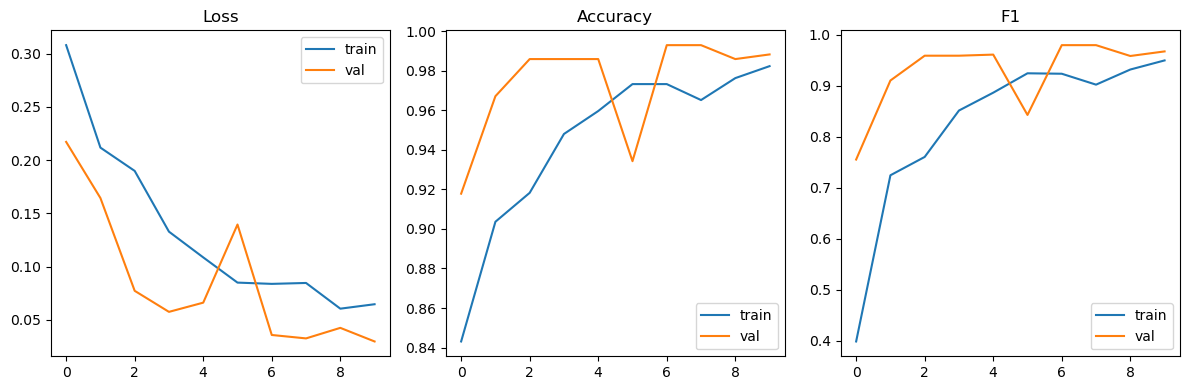

In [20]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.plot(history["train_loss"], label="train")
plt.plot(history["val_loss"], label="val")
plt.title("Loss")
plt.legend()

plt.subplot(1,3,2)
plt.plot(history["train_acc"], label="train")
plt.plot(history["val_acc"], label="val")
plt.title("Accuracy")
plt.legend()

plt.subplot(1,3,3)
plt.plot(history["train_f1"], label="train")
plt.plot(history["val_f1"], label="val")
plt.title("F1")
plt.legend()

plt.tight_layout()
plt.show()

In [21]:
@torch.no_grad()
def extract_embeddings(model, df_subset, out_size=224):
    model.eval()
    embs = []

    for _, row in df_subset.iterrows():
        x = preprocess_npz(row["path"], margin=5, out_size=out_size)
        x = torch.from_numpy(x).permute(2, 0, 1).unsqueeze(0).to(device)

        logits, emb = model(x)
        embs.append(emb.cpu().numpy()[0])

    return np.stack(embs, axis=0)

train_emb = extract_embeddings(cnn_model, train_df, out_size=OUT_SIZE)
val_emb   = extract_embeddings(cnn_model, val_df, out_size=OUT_SIZE)
test_emb  = extract_embeddings(cnn_model, test_df, out_size=OUT_SIZE)

print(train_emb.shape, val_emb.shape, test_emb.shape)

(1982, 128) (426, 128) (425, 128)


In [22]:
X_train = pd.DataFrame(train_emb, columns=[f"emb_{i}" for i in range(train_emb.shape[1])])
X_val   = pd.DataFrame(val_emb, columns=[f"emb_{i}" for i in range(val_emb.shape[1])])
X_test  = pd.DataFrame(test_emb, columns=[f"emb_{i}" for i in range(test_emb.shape[1])])

y_train = train_df["task4_label"].astype(int).reset_index(drop=True)
y_val   = val_df["task4_label"].astype(int).reset_index(drop=True)
y_test  = test_df["task4_label"].astype(int).reset_index(drop=True)

xgb_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("classifier", XGBClassifier(
        n_estimators=400,
        max_depth=5,
        learning_rate=0.03,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=19,
        n_jobs=-1
    ))
])

xgb_model.fit(X_train, y_train)

val_probs = xgb_model.predict_proba(X_val)[:, 1]
test_probs = xgb_model.predict_proba(X_test)[:, 1]

In [23]:
thresholds = np.arange(0.10, 0.91, 0.01)

best_threshold = None
best_metrics = None
best_acc = -1

for t in thresholds:
    val_pred = (val_probs >= t).astype(int)
    acc = accuracy_score(y_val, val_pred)
    f1 = f1_score(y_val, val_pred, zero_division=0)

    if acc > best_acc:
        best_acc = acc
        best_threshold = t
        best_metrics = {"acc": acc, "f1": f1}

print("Best threshold:", best_threshold)
print("Best val metrics:", best_metrics)

Best threshold: 0.1
Best val metrics: {'acc': 0.9929577464788732, 'f1': 0.9795918367346939}


In [24]:
test_pred = (test_probs >= best_threshold).astype(int)

test_metrics = {
    "acc": accuracy_score(y_test, test_pred),
    "f1": f1_score(y_test, test_pred, zero_division=0)
}

print("Test metrics:")
print(test_metrics)
print()
print(classification_report(y_test, test_pred, zero_division=0))

Test metrics:
{'acc': 0.9905882352941177, 'f1': 0.9733333333333334}

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       350
           1       0.97      0.97      0.97        75

    accuracy                           0.99       425
   macro avg       0.98      0.98      0.98       425
weighted avg       0.99      0.99      0.99       425



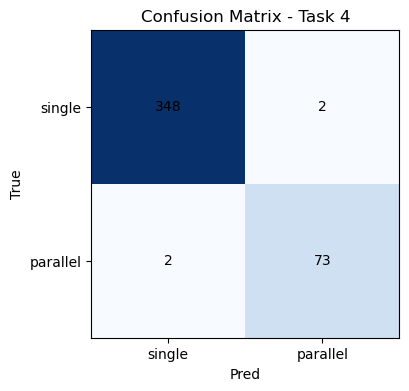

In [25]:
cm = confusion_matrix(y_test, test_pred)

plt.figure(figsize=(5,4))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix - Task 4")
plt.xticks([0,1], ["single", "parallel"])
plt.yticks([0,1], ["single", "parallel"])
plt.xlabel("Pred")
plt.ylabel("True")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

In [26]:
clf = xgb_model.named_steps["classifier"]

importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": clf.feature_importances_
}).sort_values("importance", ascending=False)

display(importance_df.head(20))

,feature,importance
74,emb_74,0.405995
89,emb_89,0.162073
99,emb_99,0.083343
70,emb_70,0.059886
1,emb_1,0.053124
108,emb_108,0.048053
23,emb_23,0.042583
84,emb_84,0.041333
96,emb_96,0.014029
94,emb_94,0.012448


In [27]:
@torch.no_grad()
def predict_one_image_task4(npz_path, threshold=0.5):
    x = preprocess_npz(npz_path, margin=5, out_size=OUT_SIZE)
    xt = torch.from_numpy(x).permute(2, 0, 1).unsqueeze(0).to(device)

    logits, emb = cnn_model(xt)
    emb = emb.cpu().numpy()

    X_one = pd.DataFrame(emb, columns=[f"emb_{i}" for i in range(emb.shape[1])])
    prob = xgb_model.predict_proba(X_one)[:, 1][0]
    pred = 1 if prob >= threshold else 0

    return pred, float(prob)

In [28]:
npz_path = test_df.iloc[0]["path"]

pred, prob = predict_one_image_task4(npz_path, threshold=best_threshold)

print("Fichier :", os.path.basename(npz_path))
print("Prediction :", pred, "(0=single, 1=parallel)")
print("Probabilité :", round(prob, 4))

row = df[df[FILE_COL] == os.path.basename(npz_path)]
if len(row) > 0:
    print("Pipe type réel :", row.iloc[0]["pipe_type"])
    print("Label réel task4 :", int(row.iloc[0]["task4_label"]))

Fichier : sample_01877_no_pipe_curved_clean_field.npz
Prediction : 0 (0=single, 1=parallel)
Probabilité : 0.0005
Pipe type réel : single
Label réel task4 : 0


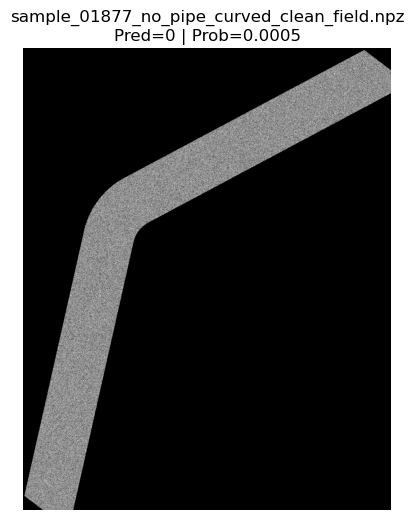

In [29]:
x = load_npz(npz_path)

if x.shape[-1] >= 4:
    img = x[..., 3]
else:
    img = np.linalg.norm(np.nan_to_num(x), axis=-1)

img = np.nan_to_num(img, nan=0.0)

plt.figure(figsize=(6,6))
plt.imshow(img, cmap="gray")
plt.title(f"{os.path.basename(npz_path)}\nPred={pred} | Prob={prob:.4f}")
plt.axis("off")
plt.show()